In [2]:
# data from Rebboah et al. https://doi.org/10.1101/2025.04.21.649844 
import numpy as np
import pandas as pd 

import anndata as ad
import scanpy as sc

import sklearn
import scipy
from sklearn.decomposition import PCA
from scipy.linalg import eigh

import seaborn as sns
import matplotlib.pyplot as plt


def standardize_array(array):
        standardized_array =  (array-np.mean(array,axis=0)) / np.std(array,axis=0)
        return np.nan_to_num(standardized_array)

In [3]:
adata = ad.read_h5ad('/home/8cube/parse_pipeline/IGVF_analysis/annotated_tissues/Kidney_annotated.h5ad')
adata.X = adata.layers["cellbender_counts"].copy()

In [4]:
# select genotype and remove low quality cells
genotype = 'B6J'
adata_b6 = adata[(adata.obs.Genotype==genotype)&(adata.obs.celltype!='low quality')]

/tmp/ipykernel_884033/600652438.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["celltype", "Sex"])
/tmp/ipykernel_884033/600652438.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("celltype")["count"]


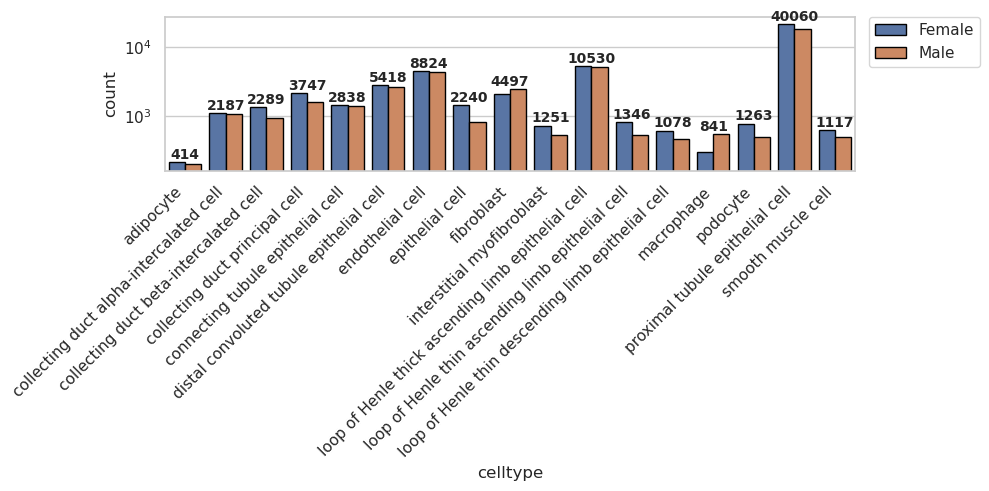

In [5]:
# number of cells per cell type per individual

# Build the count dataframe
df = (
    adata_b6.obs
    .groupby(["celltype", "Sex"])
    .size()
    .reset_index(name="count")
)

# Compute totals per celltype (for the group label)
totals = (
    df.groupby("celltype")["count"]
    .sum()
    .reset_index()
    .rename(columns={"count": "total"})
)

plt.figure(figsize=(10, 5))
sns.set(style="whitegrid")

ax = sns.barplot(
    data=df,
    x="celltype",
    y="count",
    hue="Sex",
    edgecolor="black"
)


ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

# ---- Add ONE number per celltype above the group ----
# Find the positions of each x tick and label
x_positions = range(len(totals))

for x, total in zip(x_positions, totals["total"]):
    # Find the highest bar in the group to position label above it
    group_max = df[df["celltype"] == totals.loc[x, "celltype"]]["count"].max()
    
    ax.text(
        x, group_max + 5,           # y-offset so the number sits above bars
        str(total),
        ha="center", va="bottom",
        fontsize=10, fontweight="bold"
    )

plt.xticks(rotation=45, ha="right")
plt.yscale('log')
plt.tight_layout()
plt.show()

In [6]:
# select genes with high expression 
sums = np.array(adata_b6.X.sum(axis=0)).flatten()
filt1 = sums > np.quantile(sums,.80)

adata_b6 = adata_b6[:,filt1].copy()

In [7]:
# normalize, then select highly variable genes
sc.pp.normalize_total(adata_b6,target_sum=10000)
sc.pp.log1p(adata_b6) 

In [8]:
# separate and select highly variable genes (2000)
adata_target = adata_b6[adata_b6.obs.Sex=='Female']
adata_background = adata_b6[adata_b6.obs.Sex=='Male']

sc.pp.highly_variable_genes(adata_target,n_top_genes=2000)

filt = adata_target.var.highly_variable.values
adata_target = adata_target[:,filt]
adata_background = adata_background[:,filt]

target = adata_target.X.toarray()
background = adata_background.X.toarray()

/home/mcarilli/miniconda3/envs/scenv/lib/python3.13/site-packages/scanpy/preprocessing/_highly_variable_genes.py:705: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


In [9]:
filt = adata_target.var.highly_variable.values
adata_target[:,filt]

View of AnnData object with n_obs × n_vars = 47798 × 2000
    obs: 'lab_sample_id', 'sample', 'plate', 'subpool', 'SampleType', 'Tissue', 'Sex', 'Age', 'Genotype', 'subpool_type', 'Protocol', 'Chemistry', 'bc', 'bc1_sequence', 'bc2_sequence', 'bc3_sequence', 'bc1_well', 'bc2_well', 'bc3_well', 'Row', 'Column', 'well_type', 'Mouse_Tissue_ID', 'Multiplexed_sample1', 'Multiplexed_sample2', 'DOB', 'Age_days', 'Body_weight_g', 'Estrus_cycle', 'Dissection_date', 'Dissection_time', 'ZT', 'Dissector', 'Tissue_weight_mg', 'Notes', 'n_genes_by_counts_raw', 'total_counts_raw', 'total_counts_mt_raw', 'pct_counts_mt_raw', 'n_genes_by_counts_cb', 'total_counts_cb', 'total_counts_mt_cb', 'pct_counts_mt_cb', 'doublet_score', 'predicted_doublet', 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'leiden', 'leiden_R', 'general_celltype', 'general_CL_ID', 'celltype', 'CL_ID', 'subtype'
    var: 'gene_id', 'gene_name', 'mt', 'highly_variable', 'means', 'dispersions', 'dispersio

In [10]:
adata_target = adata_target[:,filt]
adata_background = adata_background[:,filt]

In [ ]:
# save 
# adata_target.write_h5ad('./data/adata_female.h5ad')
# adata_background.write_h5ad('./data/adata_male.h5ad')

# PCA

In [11]:
# do pca 
both = np.concatenate([target,background])
both_std = standardize_array(both)

target_std = standardize_array(target)
background_std = standardize_array(background)

In [12]:
n_components = 50 
pca = PCA(n_components=n_components)
both_pca = pca.fit_transform(both_std)

# project just target 
target_pca = pca.transform(target_std) 
background_pca = pca.transform(background_std)

# rhoPCA

In [13]:
# Rayleigh quotient 

# --- Rayleigh Quotient projection (2D) ---
Sigma_t = np.cov(target_std, rowvar=False)
Sigma_b = np.cov(background_std, rowvar=False)

eigvals_rq, eigvecs_rq = eigh(Sigma_t, Sigma_b)

# Take top 2 generalized eigenvectors
V_rq = eigvecs_rq[:, -3:]  
target_proj_rq = target_std @ V_rq  
background_proj_rq = background_std @ V_rq

rayleigh_proj = np.concatenate([target_proj_rq,background_proj_rq]) 

### Calculate rho per cell type 

In [14]:
# get cell type variance

ct_var_list = [] 
for ct in adata_target.obs.celltype.unique():
    filtf = adata_target.obs.celltype==ct
    filtm = adata_background.obs.celltype==ct

    for i in range(3):
        xm = background_proj_rq[filtm,-(i+1)]
        xf = target_proj_rq[filtf,-(i+1)]

        xm_pca = background_pca[filtm,i]
        xf_pca = target_pca[filtf,i]

        ct_var_list.append({'celltype' : ct,
                            'Variance' : np.var(xm),
                            'Sex' : 'male',
                            'Type' : 'GE',
                            'Num' : i})
        ct_var_list.append({'celltype' : ct,
                            'Variance' : np.var(xf),
                            'Sex' : 'female',
                            'Type' : 'GE',
                            'Num' : i})
        ct_var_list.append({'celltype' : ct,
                            'Variance' : np.var(xm_pca),
                            'Sex' : 'male',
                            'Type' : 'PC',
                            'Num' : i})
        ct_var_list.append({'celltype' : ct,
                            'Variance' : np.var(xm_pca),
                            'Sex' : 'female',
                            'Type' : 'PC',
                            'Num' : i})

        
        
ct_var_df = pd.DataFrame(ct_var_list)

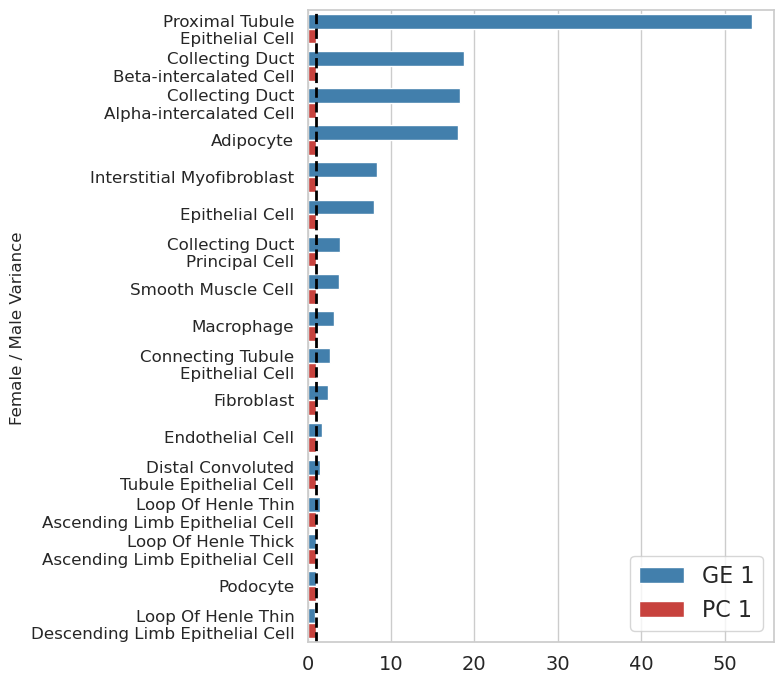

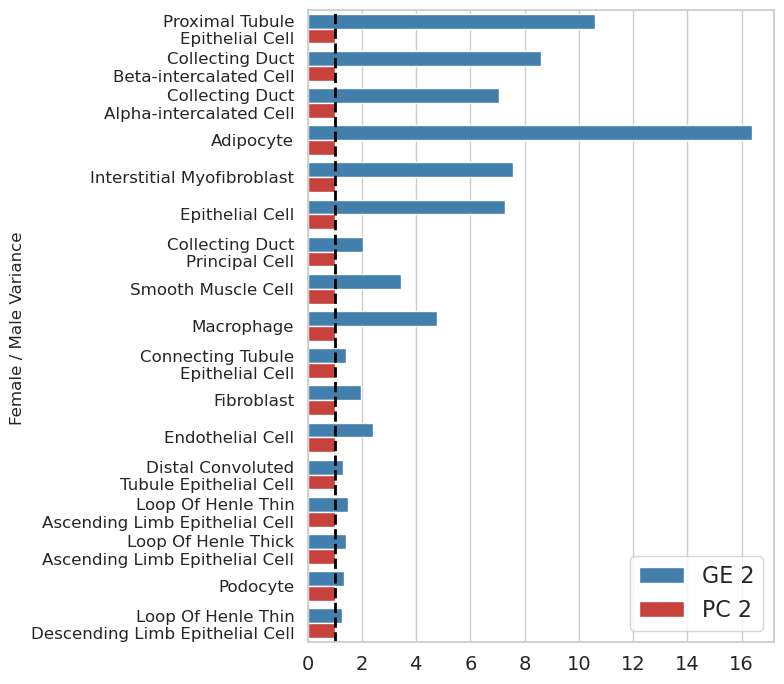

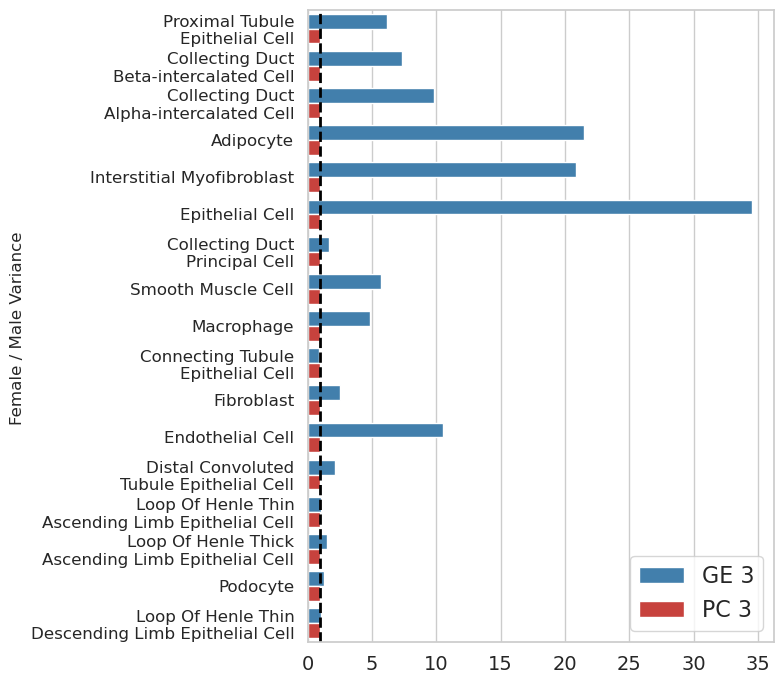

In [15]:
import re

# Function to format cell type labels
def format_celltype(name):
    # Capitalize first letter of each word
    words = name.split()
    words = [w.capitalize() for w in words]
    # If >3 words, insert line break after 2nd word
    if len(words) > 3:
        int_ = int(len(words)/2)
        name = ' '.join(words[:int_]) + '\n' + ' '.join(words[int_:])
    else:
        name = ' '.join(words)
    return name


for i in range(2):
    ratio_df1 = (
        ct_var_df[ct_var_df.Num == i]
        .pivot_table(index=['celltype', 'Type'], columns='Sex', values='Variance')
        .reset_index()
    )
    
    # Ensure both sexes are present
    ratio_df1 = ratio_df1.dropna(subset=['female', 'male'])
    
    # Compute the ratio
    ratio_df1['Female_to_Male'] = ratio_df1['female'] / ratio_df1['male']
    
    # Apply formatting to a copy of the DataFrame for plotting
    ratio_df1 = ratio_df1.copy()
    ratio_df1['celltype_fmt'] = ratio_df1['celltype'].apply(format_celltype)
    
    
    # Compute ordering by descending GE ratio
    if i == 0:
        ge_order = (
            ratio_df1[ratio_df1['Type'] == 'GE']
            .sort_values('Female_to_Male', ascending=False)['celltype_fmt']
        )
    
    # Plot with that order
    plt.figure(figsize=(8,7))
    sns.barplot(
        data=ratio_df1,
        y='celltype_fmt',
        x='Female_to_Male',
        hue='Type',
        order=ge_order, 
        palette={'PC':'#de2d26', 'GE':'#3182bd'}
    )
    plt.axvline(1, color='black', linestyle='--', lw=2)
    plt.ylabel('Female / Male Variance ')
    plt.xlabel('')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=12)
    
    # Update legend labels
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles, [f'GE {i+1}', f'PC {i+1}'], title='', fontsize = 16,loc='lower right')
    
    plt.tight_layout()
    plt.show()


In [18]:
ct_var_df

,celltype,Variance,Sex,Type,Num
0,collecting duct beta-intercalated cell,0.538710,male,GE,0
1,collecting duct beta-intercalated cell,10.113357,female,GE,0
2,collecting duct beta-intercalated cell,14.812340,male,PC,0
3,collecting duct beta-intercalated cell,14.812340,female,PC,0
4,collecting duct beta-intercalated cell,0.587115,male,GE,1
...,...,...,...,...,...
199,endothelial cell,2.104846,female,PC,1
200,endothelial cell,0.938881,male,GE,2
201,endothelial cell,9.889007,female,GE,2
202,endothelial cell,12.996040,male,PC,2


/tmp/ipykernel_884033/110457238.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['celltype_fmt'] = df1['celltype'].apply(format_celltype)
/tmp/ipykernel_884033/110457238.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Sex-Method'] = df1['Sex'].astype('str') + '-' + df1['Type'].astype('str')


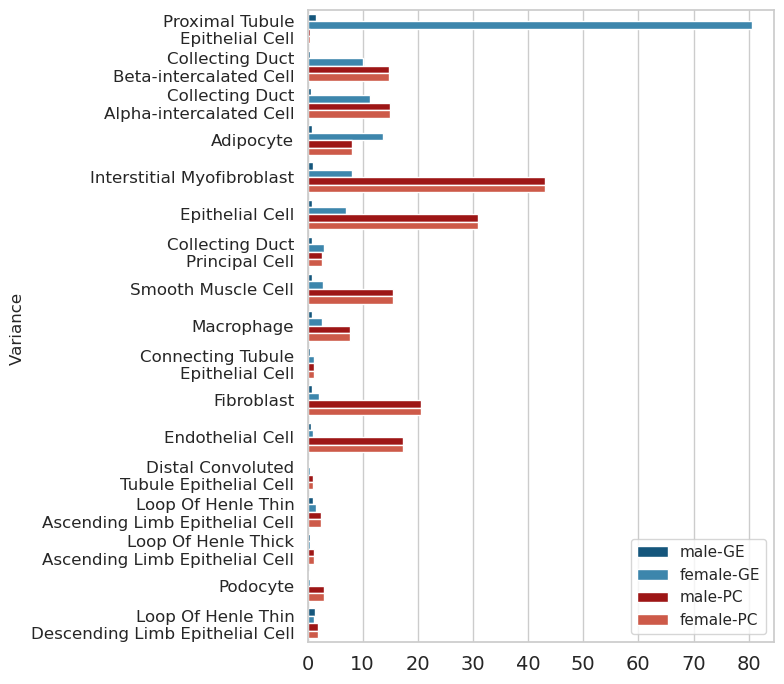

/tmp/ipykernel_884033/110457238.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['celltype_fmt'] = df1['celltype'].apply(format_celltype)
/tmp/ipykernel_884033/110457238.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Sex-Method'] = df1['Sex'].astype('str') + '-' + df1['Type'].astype('str')


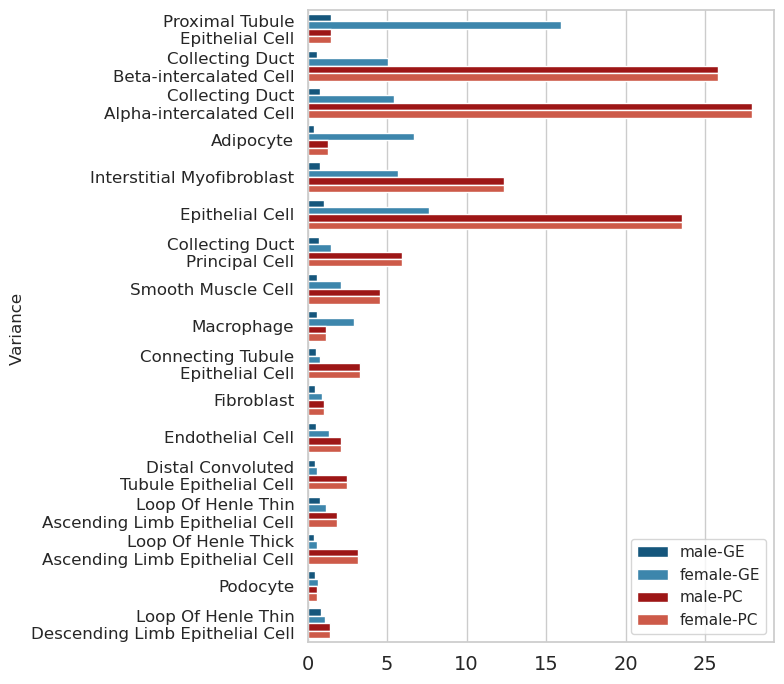

In [25]:
for i in range(2):
    df1 = ct_var_df[ct_var_df.Num == i]

    # Apply formatting to a copy of the DataFrame for plotting
    df1['celltype_fmt'] = df1['celltype'].apply(format_celltype)
    
    df1['Sex-Method'] = df1['Sex'].astype('str') + '-' + df1['Type'].astype('str')
    
    # Plot with that order
    plt.figure(figsize=(8,7))
    sns.barplot(
        data=df1,
        y='celltype_fmt',
        x='Variance',
        hue='Sex-Method',
        order=ge_order,
        palette={'female-PC':'#e34a33',
                 'male-PC':'#b30000',
                 'female-GE':'#2b8cbe',
                 'male-GE':'#045a8d',}
    )
    # plt.axvline(1, color='black', linestyle='--', lw=2)
    plt.ylabel('Variance ')
    plt.xlabel('')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=12)
    
    # Update legend labels
    # handles, labels = plt.gca().get_legend_handles_labels()
    # plt.legend(handles, [f'GE {i+1}', f'PC {i+1}'], title='', fontsize = 16,loc='lower right')
    plt.legend()
    plt.tight_layout()
    plt.show()

### Plot projections on first two PCs

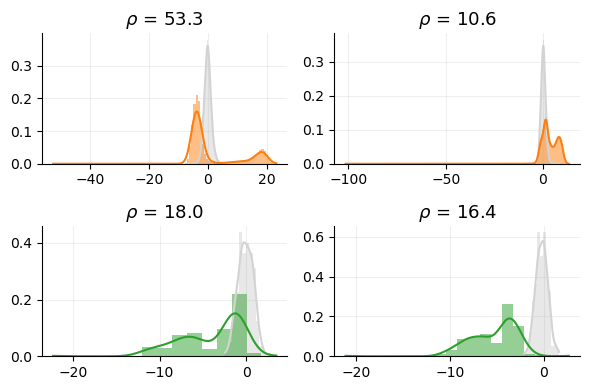

In [15]:

cts = ['proximal tubule epithelial cell','adipocyte']


colors = [
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    # "#d62728",  # red
    "#9467bd",  # purple
    "#e377c2",  # pink
    # "#7f7f7f",  # gray
    # "#bcbd22",  # yellow-green
    # "#17becf",  # cyan
    # "#aec7e8",  # light blue
    # "#ffbb78",  # light orange
    # "#98df8a",  # light green
    # "#ff9896",  # light red
    # "#c5b0d5",  # light purple
    # "#c49c94",  # light brown,
    # "magenta"   # magenta 
]

color_dict = {ct : colors[c] for c,ct in enumerate(cts)}



fig, ax = plt.subplots(len(cts), 2, figsize=(6, 4), sharex=False, sharey=False)


for c, ct in enumerate(cts):
    filtf = adata_target.obs.celltype == ct
    filtm = adata_background.obs.celltype == ct
    
    for i in range(2):
        xf = target_proj_rq[filtf, -(i+1)]       # female or foreground
        xm = background_proj_rq[filtm, -(i+1)]      # male or background
        ratio = np.var(xf)/np.var(xm)
        
        sns.histplot(xm, kde=True, stat="density",
                     color='lightgray', alpha=0.5, ax=ax[c, i], linewidth=0,label='Male')

        
        sns.histplot(xf, kde=True, stat="density",
                     color=color_dict[ct], alpha=0.5, ax=ax[c, i], linewidth=0,label='Female')
        
        # Aesthetics
        # ax[c, i].set_title(f"{ct} — PC{i+1}", fontsize=12)
        ax[c, i].grid(alpha=0.2)
        ax[c, i].spines['top'].set_visible(False)     # remove top spine
        ax[c, i].spines['right'].set_visible(False)   # remove right spine
        if i == 2:
            ax[c,i].legend(fontsize=15,loc='upper right')
        # if i == 0:
        #         ax[c, i].text(
        #             0.03, 0.90, ct.capitalize(),
        #             transform=ax[c, i].transAxes,
        #             fontsize=15,
        #             # fontweight='bold',
        #             color='black',
        #             bbox=dict(facecolor='white',edgecolor='lightgray', alpha=1.0, boxstyle='round')
        #         )
        ax[c,i].set_ylabel('')
        ax[c, i].set_title(
                r'$\rho$ = ' + f'{ratio:.1f}',                
                fontsize=13,
            )


# Layout
# for i in range(len(cts)):
#     diag_xlim = ax[i, i].get_xlim()  # get x limits from diagonal subplot
#     for j in range(3):  # loop through columns in the same row
#         ax[j, i].set_xlim(diag_xlim)

plt.tight_layout()
plt.show()




### Get top genes on GE 1 and GE 2 

1
2


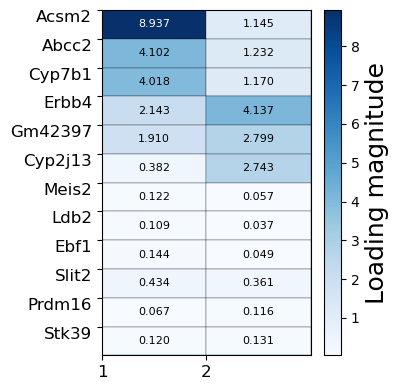

In [16]:
loadings = eigvecs_rq * np.sqrt(eigvals_rq)
n_ge = 2
# select top genes in terms of all loadings
# gene_scores = np.linalg.norm(loadings, axis=1)

top_genes = []
gene_idx = []
for i in range(1,3):
    print(i)
    gene_scores = np.abs(eigvecs_rq[:,-i])
    idx_ = np.argsort(gene_scores)[-3:][::-1]
    gene_idx += list(idx_)
    genes_ = list(adata_target.var.iloc[idx_].index.values)
    top_genes += genes_


for i in range(0,2):
    gene_scores = np.abs(pca.components_[i,:])
    idx_ = np.argsort(gene_scores)[-3:][::-1]
    gene_idx += list(idx_)
    genes_ = list(adata_target.var.iloc[idx_].index.values)
    top_genes += genes_




heatmap_data = loadings[gene_idx][:, -n_ge:]
heatmap_data = heatmap_data[:, ::-1]
abs_data = np.abs(heatmap_data)

plt.figure(figsize=(4,4))

im = plt.pcolormesh(
    abs_data,
    cmap='Blues',
    edgecolors='black',   # draw lines between pixels
    linewidth=0.2,        # thin lines
    antialiased=True
)

for i in range(abs_data.shape[0]):
    for j in range(abs_data.shape[1]):
        val_ = abs_data[i, j]
        if val_ >= 5.0:
            c = 'white'
        else:
            c = 'black'
        plt.text(
            j + 0.5, i + 0.5,                     # center of each cell
            f"{val_:.3f}",              # 1 decimal place
            ha='center', va='center', fontsize=8, color=c
        )

plt.gca().invert_yaxis()  # to match imshow orientation


cbar = plt.colorbar(im, label='Loading magnitude')
cbar.set_label('Loading magnitude', fontsize=18)

plt.xticks(range(0,n_ge,1), np.arange(1,1+n_ge,1), fontsize=12,)
plt.yticks(range(len(top_genes)), top_genes, fontsize=12, va = 'top')

# plt.xlabel("Generalized eigenvector\nloadings", fontsize=14)
# plt.ylabel("Top Genes", fontsize=14)


# for i in range(abs_data.shape[0]):      # rows (genes)
#     for j in range(abs_data.shape[1]):  # columns (PCs)
#         plt.text(j, i,
#                  f"{heatmap_data[i, j]:.2f}",
#                  ha="center", va="center",
#                  color="gray", fontsize=12)

plt.grid(False)
plt.tight_layout()
plt.show()


In [17]:
### Get top genes for PC 1 and PC 2 

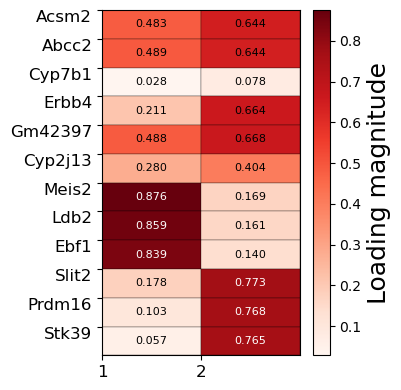

In [18]:
# top genes for PCA 


# display top 10 components of PCs
L = pca.components_.T * np.sqrt(pca.explained_variance_)
abs_pca_data = np.abs(L[gene_idx,:2])


plt.figure(figsize=(4,4))

im = plt.pcolormesh(
    abs_pca_data,
    cmap='Reds',
    edgecolors='black',   # draw lines between pixels
    linewidth=0.2,        # thin lines
    antialiased=True
)

plt.gca().invert_yaxis()  # to match imshow orientation

cbar = plt.colorbar(im, label='Loading magnitude')
cbar.set_label('Loading magnitude', fontsize=18)

plt.xticks(range(0,n_ge,1), np.arange(1,1+n_ge,1), fontsize=12,)
plt.yticks(range(len(top_genes)), top_genes, fontsize=12, va = 'top')

for i in range(abs_data.shape[0]):
    for j in range(abs_data.shape[1]):
        val_ = abs_pca_data[i, j]
        if val_ >= .7:
            c = 'white'
        else:
            c = 'black'
        plt.text(
            j + 0.5, i + 0.5,                    
            f"{val_:.3f}",              
            ha='center', va='center', fontsize=8, color=c
        )


# for i in range(abs_data.shape[0]):      # rows (genes)
#     for j in range(abs_data.shape[1]):  # columns (PCs)
#         plt.text(j, i,
#                  f"{heatmap_data[i, j]:.2f}",
#                  ha="center", va="center",
#                  color="gray", fontsize=12)

plt.tight_layout()
plt.show()

Acsm2 mean 2.180038300812275 3.5501813117183074
Erbb4 mean 0.8398619834759593 0.029011946809445528
Meis2 mean 0.03445791833359537 0.039196984019532054
Slit2 mean 0.21788551407116588 0.01354885222603774


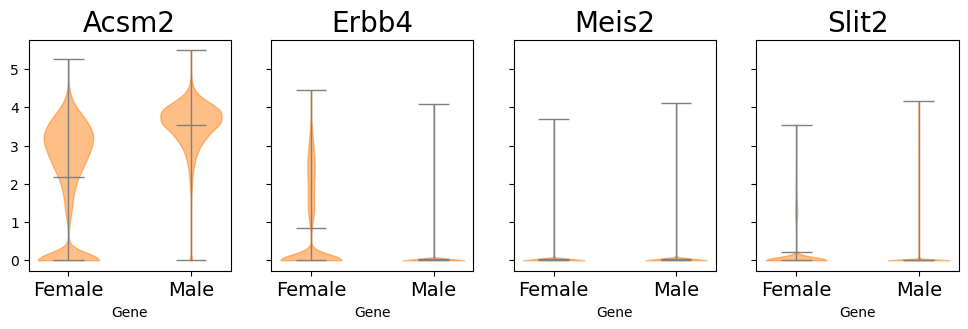

Acsm2 mean 0.02262178781426608 0.061035498730327216
Erbb4 mean 0.5956487314087954 0.30185559864448774
Meis2 mean 0.7152001518611053 0.5892582702098588
Slit2 mean 0.04399674428024818 0.0676222084229219


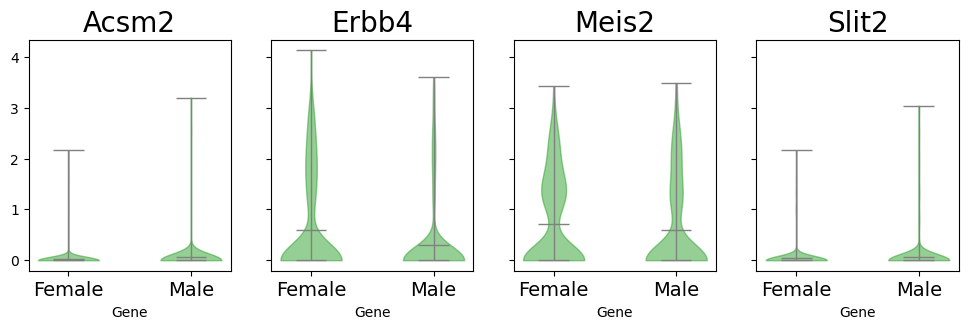

In [19]:
genes = ['Acsm2',
 # 'Abcc2',
 # 'Cyp7b1',
 'Erbb4',
 # 'Gm42397',
 # 'Cyp2j13',
 'Meis2',
 # 'Ldb2',
 # 'Ebf1',
 'Slit2',
 # 'Prdm16',
 # 'Stk39'
        ]

for c,ct in enumerate(cts):
    fig,axs = plt.subplots(1,len(genes),figsize=(12,3),sharey=True)
    # genes_ = genes[3*c:3*c+3]+['Meis2']
    for i,g in enumerate(genes):
        ax=axs[i]
        xf = adata_target[adata_target.obs.celltype==ct,adata_target.var.index == g].X.toarray().flatten()
        xm = adata_background[adata_background.obs.celltype==ct,adata_background.var.index == g].X.toarray().flatten()
        
        # Combine data into list for violinplot
        data = [xf, xm]

        
        # Violin plot
        
        parts = ax.violinplot(data, showmeans=True, showmedians=False)
        for pc in parts['bodies']:
            pc.set_facecolor(color_dict[ct])
            pc.set_edgecolor(color_dict[ct])
            pc.set_alpha(0.5)
        
        # Set mean marker/line color

        for part in ['cbars','cmeans','cmaxes','cmins']:
            parts[part].set_color('gray')    # mean color
            parts[part].set_linewidth(1)    # optional: make it thicker
        
        # Labels and style
        ax.set_xticks([1, 2])
        ax.set_xticklabels(['Female', 'Male'], fontsize=14)
        ax.set_xlabel('Gene')
        ax.set_ylabel('')
        ax.set_title(g,fontsize=20)
        print(g,'mean',np.mean(xf),np.mean(xm))
        # print(g,'variance/mean',np.var(xf)/np.mean(xf),np.var(xm)/np.mean(xm))
    plt.show()

# Timing

In [118]:
import time

In [114]:
filt_timing = sums >= np.quantile(sums,.70)
adata_timing = adata[:,filt_timing]

In [ ]:
# timing changing # samples 

samples = np.array([100,200,500,1000,5000])
samples = (samples/2).astype(int)
trials = 5 

times_c = np.ones((len(samples), trials))
times_r = np.ones((len(samples), trials))

indices = np.arange(len(adata_timing))

for i,s in enumerate(samples):
    for j in range(trials):
        print(f'Starting {s}, {j}')
        rf1 = np.random.choice(indices,size=s)
        rf2 = np.random.choice(indices,size=s)
            
        n_genes = 2000
        target_ = adata_timing[rf1].X.toarray()
        background_ = adata_timing[rf2].X.toarray()
        
        gene_filt = (target_.sum(axis=0)>0)&(background_.sum(axis=0)>0)
        target_ = target_[:,gene_filt][:,:n_genes]
        background_ = background_[:,gene_filt][:,:n_genes]

        print(target_.shape)
        n_components = min(target_.shape)

        print(n_components)
        # run cpca and store time 
        t1 = time.time()
        mdl = CPCA(n_components=2)
        mdl.fit(target_, background_,preprocess_with_pca_dim=n_components)
        _ = mdl.transform(dataset=mdl.fg)
        t2 = time.time()
        times_c[i,j] = t2 - t1
        print(f'done with {s}, {j}, cPCA')

        # run rayleigh and store time 
        t1 = time.time()
        Sigma_t = np.cov(target_, rowvar=False)
        Sigma_b = np.cov(background_, rowvar=False)
        try: 
            eigvals_rq, eigvecs_rq = eigh(Sigma_t, Sigma_b_reg)
        except:
            eps = 1e-6 * np.trace(Sigma_b) / Sigma_b.shape[0]  # scale regularization if not positive definite
            Sigma_b_reg = Sigma_b + eps * np.eye(Sigma_b.shape[0])
            eigvals_rq, eigvecs_rq = eigh(Sigma_t, Sigma_b_reg)
        V_rq = eigvecs_rq[:, -2:]  
        target_proj_rq = target_std @ V_rq  
        t2 = time.time()
        
        times_r[i,j] = t2 - t1
        print(f'done with {s}, {j}, RQ')

    


Starting 50, 0
(50, 2000)
50
done with 50, 0, cPCA
done with 50, 0, RQ
Starting 50, 1
(50, 2000)
50
done with 50, 1, cPCA
done with 50, 1, RQ
Starting 50, 2
(50, 2000)
50
done with 50, 2, cPCA
done with 50, 2, RQ
Starting 50, 3
(50, 2000)
50
done with 50, 3, cPCA
done with 50, 3, RQ
Starting 50, 4
(50, 2000)
50
done with 50, 4, cPCA
done with 50, 4, RQ
Starting 100, 0
(100, 2000)
100
done with 100, 0, cPCA
done with 100, 0, RQ
Starting 100, 1
(100, 2000)
100
done with 100, 1, cPCA
done with 100, 1, RQ
Starting 100, 2
(100, 2000)
100
done with 100, 2, cPCA
done with 100, 2, RQ
Starting 100, 3
(100, 2000)
100
done with 100, 3, cPCA
done with 100, 3, RQ
Starting 100, 4
(100, 2000)
100
done with 100, 4, cPCA
done with 100, 4, RQ
Starting 250, 0
(250, 2000)
250
done with 250, 0, cPCA
done with 250, 0, RQ
Starting 250, 1
(250, 2000)
250
done with 250, 1, cPCA
done with 250, 1, RQ
Starting 250, 2
(250, 2000)
250
done with 250, 2, cPCA
done with 250, 2, RQ
Starting 250, 3
(250, 2000)
250
done 

In [ ]:
# save timing 
# !mkdir results
np.save('./results/timing_cpca.npy',times_c)
np.save('./results/timing_rayleigh.npy',times_r)

In [550]:
# load in figures

times_c = np.load('./results/timing_cpca.npy')
times_r = np.load('./results/timing_rayleigh.npy')

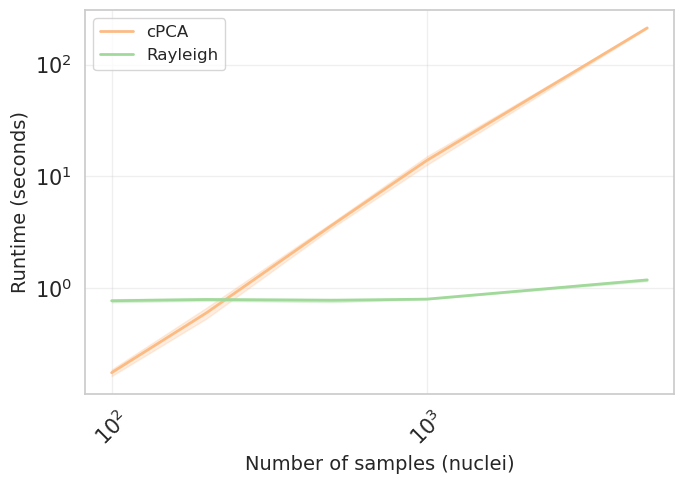

In [551]:
samples = np.array([100,200,500,1000,5000])


# Compute mean and std across trials (axis=1 because rows = sample sizes)
mean_c = times_c.mean(axis=1)
std_c  = times_c.std(axis=1)

mean_r = times_r.mean(axis=1)
std_r  = times_r.std(axis=1)

# Plot
plt.figure(figsize=(7,5))

# cPCA line and shading
plt.plot(samples, mean_c, label="cPCA", linewidth=2, color = '#fdbb84')
plt.fill_between(samples, mean_c-std_c, mean_c+std_c, alpha=0.25, color = '#fdbb84')

# Rayleigh line and shading
plt.plot(samples, mean_r, label="Rayleigh", linewidth=2,  color = '#a1d99b')
plt.fill_between(samples, mean_r-std_r, mean_r+std_r, alpha=0.25,  color = '#a1d99b')

# Formatting
plt.xlabel("Number of samples (nuclei)", fontsize=14)
plt.ylabel("Runtime (seconds)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.yscale('log')
plt.tick_params(axis='both', labelsize=15)
plt.xticks(rotation=45)
plt.xscale('log')


plt.tight_layout()
plt.show()


In [ ]:
# Timing changing # features
features = np.array([100,200,500,1000,5000,10000,15000])

trials = 5 

times_cf = np.ones((len(features), trials))
times_rf = np.ones((len(samples), trials))

indices = np.arange(len(adata_timing.var))

for i,f in enumerate(features):
    for j in range(trials):
        print(f'Starting {f}, {j}')
        rf1 = np.random.choice(indices,size=f)
        rf2 = np.random.choice(indices,size=f)

        # if s < 2000:
        #     n_genes = s 
        # else:
        #     n_genes = 2000
            
        target_ = adata_timing[:1000,rf1].X.toarray()
        background_ = adata_timing[:1000,rf2].X.toarray()
        
        # gene_filt = (target_.sum(axis=0)>0)&(background_.sum(axis=0)>0)
        # target_ = target_[:,gene_filt][:,:n_genes]
        # background_ = background_[:,gene_filt][:,:n_genes]

        print(target_.shape)
        n_components = f

        print(n_components)
        # run cpca and store time 
        t1 = time.time()
        mdl = CPCA(n_components=2)
        mdl.fit(target_, background_,preprocess_with_pca_dim=n_components)
        _ = mdl.transform(dataset=mdl.fg)
        t2 = time.time()
        times_cf2[i,j] = t2 - t1
        print(f'done with {f}, {j}, cPCA')

        run rayleigh and store time 
        t1 = time.time()
        Sigma_t = np.cov(target_, rowvar=False)
        Sigma_b = np.cov(background_, rowvar=False)
        try: 
            eigvals_rq, eigvecs_rq = eigh(Sigma_t, Sigma_b_reg)
        except:
            eps = 1e-6 * np.trace(Sigma_b) / Sigma_b.shape[0]  # scale regularization if not positive definite
            Sigma_b_reg = Sigma_b + eps * np.eye(Sigma_b.shape[0])
            eigvals_rq, eigvecs_rq = eigh(Sigma_t, Sigma_b_reg)
        V_rq = eigvecs_rq[:, -2:]  
        target_proj_rq = target_ @ V_rq  
        t2 = time.time()
        
        times_rf[i,j] = t2 - t1
        print(f'done with {f}, {j}, RQ')

In [200]:
np.save('results/timing_f_cpca.npy',times_cf)
np.save('results/timing_f_rayleigh.npy',times_rf)

In [463]:
# load in timing results 
times_cf = np.load('./results/timing_f_cpca.npy')
times_rf = np.load('./results/timing_f_rayleigh.npy')

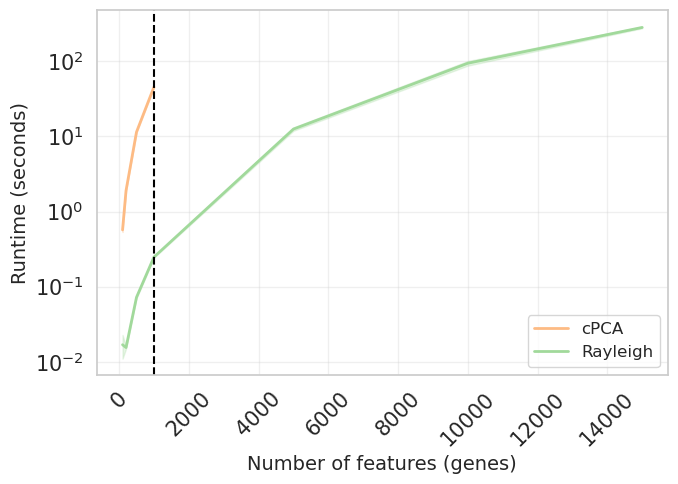

In [474]:
x = np.array([100,200,500,1000,5000,10000,15000])

# Compute mean and std across trials (axis=1 because rows = sample sizes)
mean_c = times_cf.mean(axis=1)
std_c  = times_cf.std(axis=1)

mean_r = times_rf.mean(axis=1)
std_r  = times_rf.std(axis=1)

# Plot
plt.figure(figsize=(7,5))

# cPCA line and shading
plt.plot(x[:4], mean_c[:4], label="cPCA", linewidth=2, color = '#fdbb84')
plt.fill_between(x[:4], mean_c[:4]-std_c[:4], mean_c[:4]+std_c[:4], alpha=0.25, color = '#fdbb84')

# Rayleigh line and shading
plt.plot(x, mean_r, label="Rayleigh", linewidth=2,  color = '#a1d99b')
plt.fill_between(x, mean_r-std_r, mean_r+std_r, alpha=0.25,  color = '#a1d99b')

# Formatting
plt.xlabel("Number of features (genes)", fontsize=14)
plt.ylabel("Runtime (seconds)", fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.yscale('log')
plt.tick_params(axis='both', labelsize=15)
plt.xticks(rotation=45)
plt.axvline(1000,color='black',linestyle='--')
# plt.xscale('log')


plt.tight_layout()
plt.show()